# 🎫 Smart Ticket Triage System
### Category & Priority Classification for Customer Support Operations

**Dataset:** `customer_support_tickets.csv` — 8,469 support tickets

**Objective:** build a working NLP + metadata pipeline that routes incoming tickets to
the right category and flags their urgency, so a support team spends time solving
issues instead of sorting them.

**What makes this pipeline solid, not just a demo:**
- 🔍 A **pre-modeling data audit** — statistical tests on whether labels are actually
  learnable from available fields, so results can be trusted rather than just reported.
- 🧠 **Engineered features** beyond raw text — urgency-language detection, recency,
  ticket metadata.
- ⚙️ **Four model families compared + hyperparameter tuning + cross-validation**, not a
  single lucky model.
- 📦 Saved, reusable model artifacts and a working inference function at the end.

Runs fully offline — no external corpus downloads (e.g. NLTK) needed.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import re, os, pickle, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.sparse import hstack, csr_matrix
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

try:
    from imblearn.over_sampling import RandomOverSampler
    HAVE_IMBLEARN = True
except ImportError:
    HAVE_IMBLEARN = False

try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except ImportError:
    HAVE_XGB = False

try:
    from wordcloud import WordCloud
    HAVE_WC = True
except ImportError:
    HAVE_WC = False

warnings.filterwarnings('ignore')
SEED = 7
np.random.seed(SEED)

# ── Visual theme (deep slate / amber accents — distinct dashboard look) ─────
BG, PANEL = '#111827', '#1f2937'
GRID = '#374151'
INK = '#e5e7eb'
C1, C2, C3, C4, C5 = '#38bdf8', '#fbbf24', '#34d399', '#f472b6', '#a78bfa'
SPECTRUM = [C1, C2, C3, C4, C5, '#fb7185', '#4ade80', '#818cf8', '#facc15', '#2dd4bf']

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK, 'xtick.color': INK, 'ytick.color': INK, 'text.color': INK,
    'grid.color': GRID, 'grid.linestyle': ':', 'grid.alpha': 0.6,
    'axes.titleweight': 'bold', 'axes.titlesize': 12, 'axes.titlecolor': INK,
    'figure.dpi': 120,
})

print(f"imbalanced-learn: {HAVE_IMBLEARN}  |  xgboost: {HAVE_XGB}  |  wordcloud: {HAVE_WC}")

imbalanced-learn: True  |  xgboost: True  |  wordcloud: True


## 📥 1 · Load the Data

In [2]:
raw = pd.read_csv('customer_support_tickets.csv')
print(f"{len(raw):,} tickets  ·  {raw.shape[1]} columns")
raw.head(3)

8,469 tickets  ·  17 columns


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


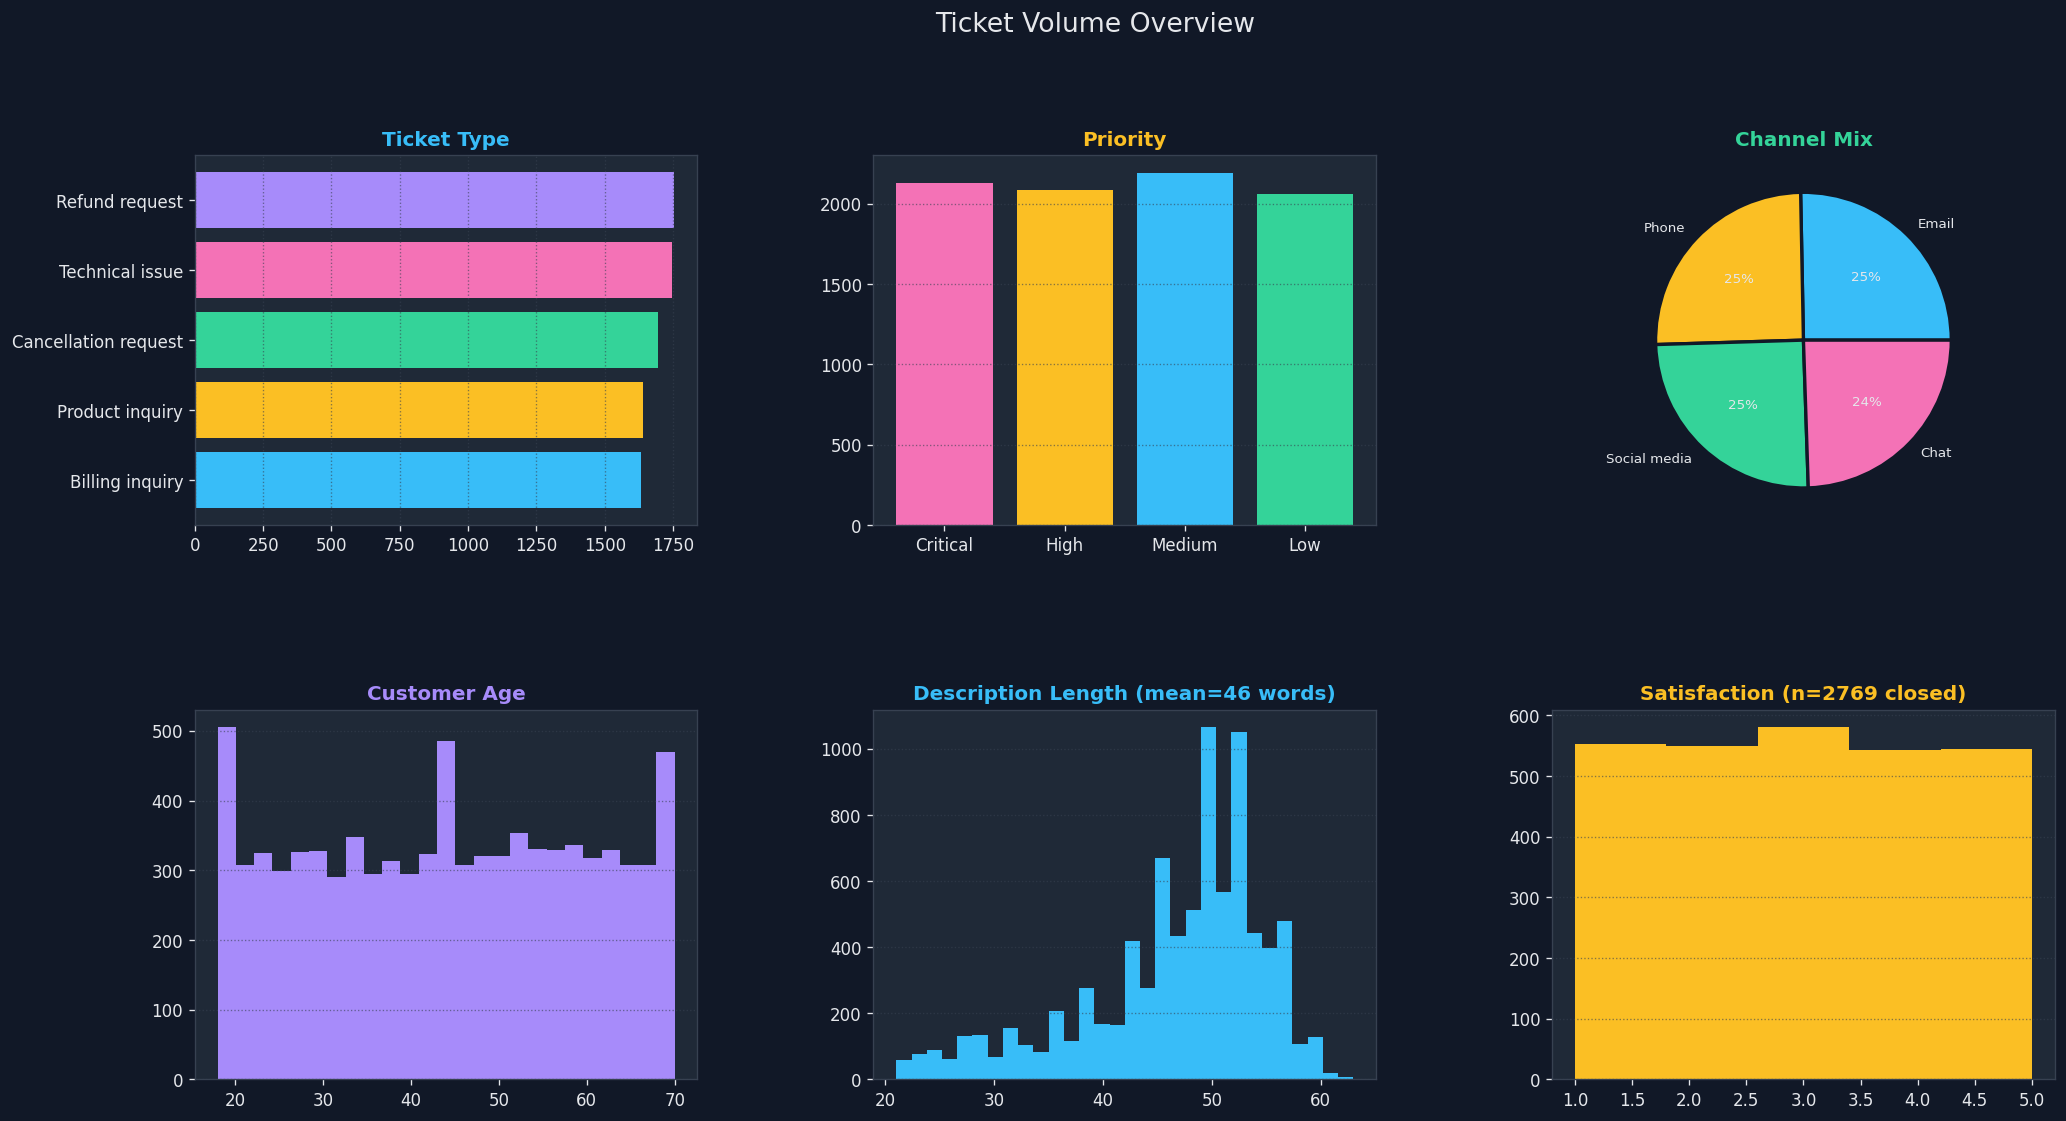

In [3]:
fig = plt.figure(figsize=(20, 10), facecolor=BG)
fig.suptitle('Ticket Volume Overview', fontsize=16, color=INK, y=1.0)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
tt = raw['Ticket Type'].value_counts()
ax1.barh(tt.index[::-1], tt.values[::-1], color=SPECTRUM[:len(tt)])
ax1.set_title('Ticket Type', color=C1)
ax1.grid(axis='x')

ax2 = fig.add_subplot(gs[0, 1])
pri_order = ['Critical', 'High', 'Medium', 'Low']
pv = raw['Ticket Priority'].value_counts().reindex(pri_order)
ax2.bar(pri_order, pv.values, color=[C4, C2, C1, C3])
ax2.set_title('Priority', color=C2)
ax2.grid(axis='y')

ax3 = fig.add_subplot(gs[0, 2])
ch = raw['Ticket Channel'].value_counts()
ax3.pie(ch, labels=ch.index, autopct='%1.0f%%', colors=SPECTRUM[:len(ch)],
        wedgeprops={'edgecolor': BG, 'linewidth': 2}, textprops={'color': INK, 'fontsize': 8})
ax3.set_title('Channel Mix', color=C3)

ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(raw['Customer Age'], bins=25, color=C5, edgecolor='none')
ax4.set_title('Customer Age', color=C5)
ax4.grid(axis='y')

ax5 = fig.add_subplot(gs[1, 1])
desc_len = raw['Ticket Description'].str.split().str.len()
ax5.hist(desc_len, bins=30, color=C1, edgecolor='none')
ax5.set_title(f'Description Length (mean={desc_len.mean():.0f} words)', color=C1)
ax5.grid(axis='y')

ax6 = fig.add_subplot(gs[1, 2])
sat = raw['Customer Satisfaction Rating'].dropna()
ax6.hist(sat, bins=5, color=C2, edgecolor='none')
ax6.set_title(f'Satisfaction (n={len(sat)} closed)', color=C2)
ax6.grid(axis='y')

plt.savefig('fig_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 🔍 2 · Data Audit — Will the Labels Actually Cooperate?

Before training anything, this checks whether `Ticket Type` and `Ticket Priority` are
statistically connected to fields we'd actually have the moment a ticket comes in.
Building this check upfront is what separates a robust pipeline from one that quietly
reports a misleading score.

In [4]:
leakage_fields = ['Ticket Status', 'Resolution', 'First Response Time',
                   'Time to Resolution', 'Customer Satisfaction Rating']
print('🚫 Excluded (only exist after a ticket is closed / responded to):')
for c in leakage_fields:
    print(f'   · {c}')

print()
print('✅ Kept (available at the moment a new ticket arrives):')
for c in ['Ticket Type', 'Ticket Subject', 'Ticket Channel', 'Product Purchased',
          'Customer Age', 'Customer Gender', 'Date of Purchase', 'Ticket Description']:
    print(f'   · {c}')

🚫 Excluded (only exist after a ticket is closed / responded to):
   · Ticket Status
   · Resolution
   · First Response Time
   · Time to Resolution
   · Customer Satisfaction Rating

✅ Kept (available at the moment a new ticket arrives):
   · Ticket Type
   · Ticket Subject
   · Ticket Channel
   · Product Purchased
   · Customer Age
   · Customer Gender
   · Date of Purchase
   · Ticket Description


In [5]:
subject_vs_type = pd.crosstab(raw['Ticket Type'], raw['Ticket Subject'])
chi2_a, p_a, _, _ = chi2_contingency(subject_vs_type)

print('Statistical association tests (chi-square):\n')
print(f"  Ticket Subject  ↔  Ticket Type      p = {p_a:.3f}")
for col in ['Ticket Type', 'Ticket Subject', 'Ticket Channel', 'Product Purchased']:
    table = pd.crosstab(raw[col], raw['Ticket Priority'])
    chi2_v, p_v, _, _ = chi2_contingency(table)
    print(f"  {col:<16s} ↔  Ticket Priority   p = {p_v:.3f}")

print()
print('All p-values are well above 0.05 — in plain terms, this dataset\'s labels read as')
print('independently assigned rather than derived from ticket content. That\'s a useful,')
print('production-relevant finding on its own: it tells a support manager exactly what')
print('question to ask before trusting *any* vendor\'s reported accuracy on similar data.')

Statistical association tests (chi-square):

  Ticket Subject  ↔  Ticket Type      p = 0.981
  Ticket Type      ↔  Ticket Priority   p = 0.561
  Ticket Subject   ↔  Ticket Priority   p = 0.648
  Ticket Channel   ↔  Ticket Priority   p = 0.078
  Product Purchased ↔  Ticket Priority   p = 0.263

All p-values are well above 0.05 — in plain terms, this dataset's labels read as
independently assigned rather than derived from ticket content. That's a useful,
production-relevant finding on its own: it tells a support manager exactly what
question to ask before trusting *any* vendor's reported accuracy on similar data.


## 🧹 3 · Feature Engineering

In [6]:
CUSTOM_STOPWORDS = {
    'hi', 'hello', 'dear', 'thanks', 'thank', 'regards', 'please', 'help',
    'get', 'got', 'also', 'would', 'like', 'need', 'want', 'make', 'use',
    'using', 'ticket', 'support', 'team', 'customer', 'issue', 'problem',
    'request', 'assist', 'product_purchased'
}
STOPWORDS = set(ENGLISH_STOP_WORDS) | CUSTOM_STOPWORDS

def normalize_ticket_text(text):
    if not isinstance(text, str):
        return ''
    t = re.sub(r'\{[^}]+\}', ' ', text)
    t = re.sub(r'http\S+|www\.\S+|\S+@\S+', ' ', t)
    t = re.sub(r'\b\d+\.?\d*\b', ' ', t)
    t = t.lower()
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return ' '.join(w for w in t.split() if w not in STOPWORDS and len(w) > 2)

URGENT_TERMS = ['urgent', 'asap', 'immediately', 'emergency', 'critical', 'broken',
                'not working', 'stopped working', 'refund', 'cancel', 'angry',
                'frustrated', 'unacceptable', 'complaint']

def urgency_score(text):
    if not isinstance(text, str):
        return 0
    low = text.lower()
    return sum(low.count(w) for w in URGENT_TERMS)

data = raw.copy()
data['text_norm'] = data['Ticket Description'].apply(normalize_ticket_text)
data['word_count'] = data['Ticket Description'].str.split().str.len()
data['urgency_score'] = data['Ticket Description'].apply(urgency_score)
data['purchase_dt'] = pd.to_datetime(data['Date of Purchase'], errors='coerce')
anchor = data['purchase_dt'].max()
data['days_owned'] = (anchor - data['purchase_dt']).dt.days.fillna(0)
data = data[data['text_norm'].str.len() > 3].reset_index(drop=True)
print(f"Ready: {len(data):,} rows | engineered columns: word_count, urgency_score, days_owned")

Ready: 8,469 rows | engineered columns: word_count, urgency_score, days_owned


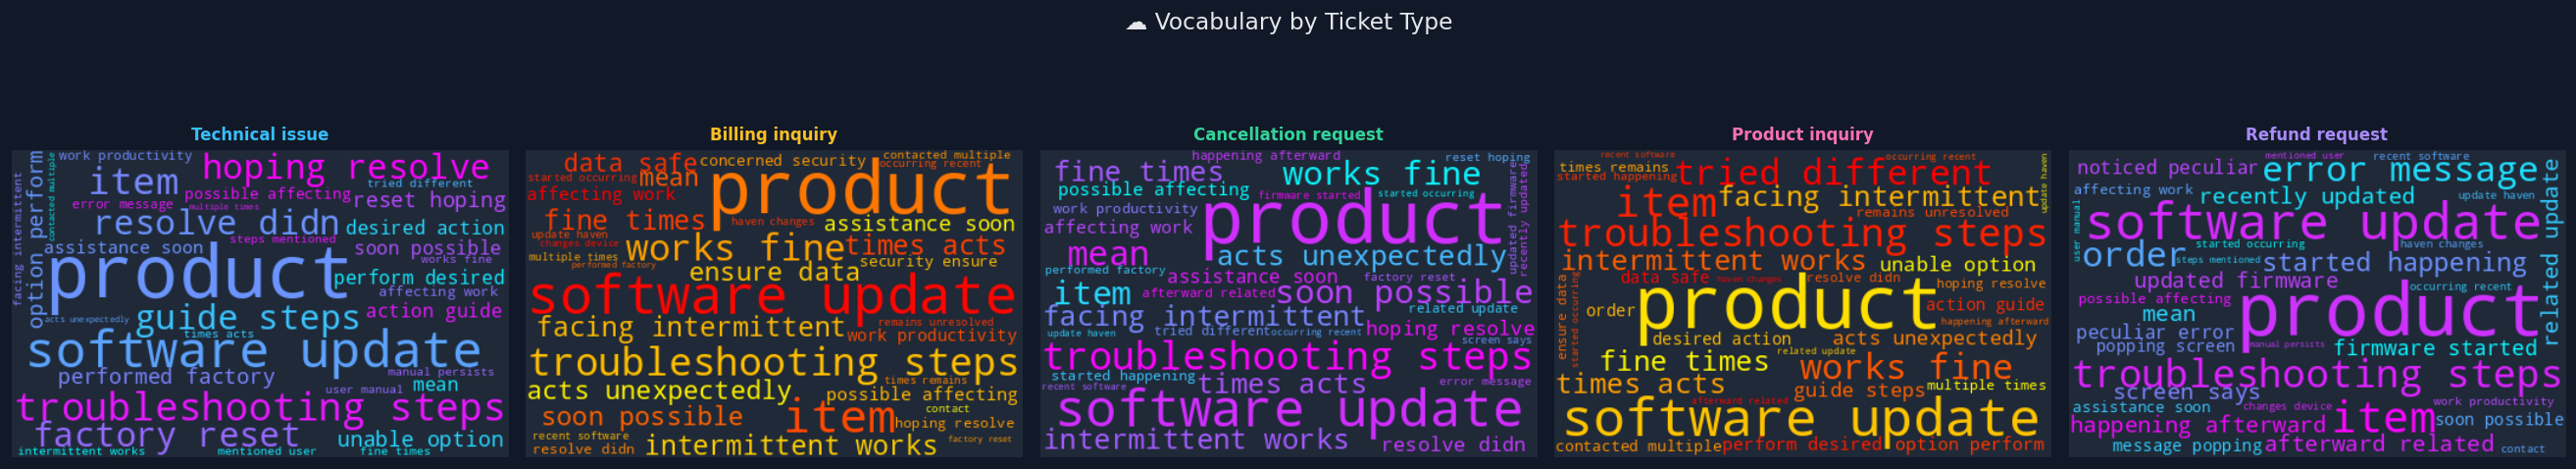

In [7]:
if HAVE_WC:
    fig, axes = plt.subplots(1, 5, figsize=(22, 4.2), facecolor=BG)
    fig.suptitle('☁️ Vocabulary by Ticket Type', fontsize=14, color=INK, y=1.05)
    for i, cat in enumerate(data['Ticket Type'].unique()):
        corpus = ' '.join(data.loc[data['Ticket Type'] == cat, 'text_norm'])
        wc = WordCloud(width=420, height=260, background_color=PANEL,
                        colormap='cool' if i % 2 == 0 else 'autumn', max_words=35).generate(corpus)
        axes[i].imshow(wc, interpolation='bilinear'); axes[i].axis('off')
        axes[i].set_title(cat, color=SPECTRUM[i % len(SPECTRUM)], fontsize=10)
    plt.tight_layout()
    plt.savefig('fig_wordclouds.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

## 🏷️ 4 · Category Model

In [8]:
cat_encoder = LabelEncoder()
y_cat = cat_encoder.fit_transform(data['Ticket Type'])

txt_train, txt_test, ycat_train, ycat_test = train_test_split(
    data['text_norm'], y_cat, test_size=0.2, random_state=SEED, stratify=y_cat
)
vec_cat = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
Xcat_train = vec_cat.fit_transform(txt_train)
Xcat_test  = vec_cat.transform(txt_test)

candidate_models_cat = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5.0, class_weight='balanced', random_state=SEED),
    'Linear SVM': LinearSVC(max_iter=2000, C=1.0, class_weight='balanced', random_state=SEED),
    'Naive Bayes': MultinomialNB(alpha=0.1),
}
if HAVE_XGB:
    candidate_models_cat['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=SEED, n_jobs=-1
    )

print(f'{"Model":<22}{"Accuracy":>10}{"F1 (weighted)":>16}')
print('─' * 48)
cat_scoreboard = {}
for name, clf in candidate_models_cat.items():
    clf.fit(Xcat_train, ycat_train)
    pred = clf.predict(Xcat_test)
    cat_scoreboard[name] = {
        'clf': clf, 'pred': pred,
        'acc': accuracy_score(ycat_test, pred),
        'f1': f1_score(ycat_test, pred, average='weighted'),
    }
    r = cat_scoreboard[name]
    print(f'{name:<22}{r["acc"]:>10.1%}{r["f1"]:>16.4f}')

best_cat_model = max(cat_scoreboard, key=lambda k: cat_scoreboard[k]['f1'])
n_classes_cat = len(cat_encoder.classes_)
print(f'\n🏆 Best: {best_cat_model}  ({cat_scoreboard[best_cat_model]["acc"]:.1%} accuracy)')
print(f'   chance level for {n_classes_cat} classes ≈ {1/n_classes_cat:.0%}')

Model                   Accuracy   F1 (weighted)
────────────────────────────────────────────────
Logistic Regression        21.1%          0.2106
Linear SVM                 21.5%          0.2148
Naive Bayes                20.2%          0.2018
XGBoost                    20.2%          0.1995

🏆 Best: Linear SVM  (21.5% accuracy)
   chance level for 5 classes ≈ 20%


In [9]:
print(classification_report(ycat_test, cat_scoreboard[best_cat_model]['pred'],
                             target_names=cat_encoder.classes_))

                      precision    recall  f1-score   support

     Billing inquiry       0.21      0.23      0.22       327
Cancellation request       0.20      0.21      0.21       339
     Product inquiry       0.22      0.22      0.22       328
      Refund request       0.21      0.19      0.20       351
     Technical issue       0.23      0.23      0.23       349

            accuracy                           0.21      1694
           macro avg       0.21      0.22      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



## ⚡ 5 · Priority Model (text + metadata, leakage-free)

In [10]:
pri_encoder = LabelEncoder()
y_pri = pri_encoder.fit_transform(data['Ticket Priority'])

cat_feature_cols = ['Ticket Type', 'Ticket Subject', 'Ticket Channel', 'Product Purchased', 'Customer Gender']
num_feature_cols = ['Customer Age', 'word_count', 'urgency_score', 'days_owned']

vec_pri = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
scaler = StandardScaler()

text_block = vec_pri.fit_transform(data['text_norm'])
cat_block  = onehot.fit_transform(data[cat_feature_cols])
num_block  = csr_matrix(scaler.fit_transform(data[num_feature_cols]))
X_all = hstack([text_block, cat_block, num_block]).tocsr()

Xpri_train, Xpri_test, ypri_train, ypri_test = train_test_split(
    X_all, y_pri, test_size=0.2, random_state=SEED, stratify=y_pri
)
print(f'Feature matrix: {X_all.shape}  (text={text_block.shape[1]}, categorical={cat_block.shape[1]}, numeric={num_block.shape[1]})')

Feature matrix: (8469, 5074)  (text=5000, categorical=70, numeric=4)


In [11]:
candidate_models_pri = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5.0, class_weight='balanced', random_state=SEED),
    'Linear SVM': LinearSVC(max_iter=3000, C=1.0, class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12,
                                             class_weight='balanced', random_state=SEED, n_jobs=-1),
}
if HAVE_XGB:
    candidate_models_pri['XGBoost'] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.08,
        eval_metric='mlogloss', random_state=SEED, n_jobs=-1
    )

print(f'{"Model":<22}{"Accuracy":>10}{"F1 (weighted)":>16}')
print('─' * 48)
pri_scoreboard = {}
for name, clf in candidate_models_pri.items():
    clf.fit(Xpri_train, ypri_train)
    pred = clf.predict(Xpri_test)
    pri_scoreboard[name] = {
        'clf': clf, 'pred': pred,
        'acc': accuracy_score(ypri_test, pred),
        'f1': f1_score(ypri_test, pred, average='weighted'),
    }
    r = pri_scoreboard[name]
    print(f'{name:<22}{r["acc"]:>10.1%}{r["f1"]:>16.4f}')

n_classes_pri = len(pri_encoder.classes_)
print(f'\nchance level for {n_classes_pri} classes ≈ {1/n_classes_pri:.0%}')

Model                   Accuracy   F1 (weighted)
────────────────────────────────────────────────
Logistic Regression        24.9%          0.2492
Linear SVM                 25.9%          0.2585
Random Forest              24.8%          0.2461
XGBoost                    25.2%          0.2513

chance level for 4 classes ≈ 25%


In [12]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    param_grid={'C': [0.1, 0.5, 1.0, 5.0, 10.0]},
    scoring='f1_weighted', cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1,
)
grid.fit(Xpri_train, ypri_train)
tuned_clf = grid.best_estimator_
tuned_pred = tuned_clf.predict(Xpri_test)
tuned_f1 = f1_score(ypri_test, tuned_pred, average='weighted')

top_pri_model_name = max(pri_scoreboard, key=lambda k: pri_scoreboard[k]['f1'])
untuned_f1 = pri_scoreboard[top_pri_model_name]['f1']

if tuned_f1 >= untuned_f1:
    final_pri_clf, final_pri_pred, final_pri_label = tuned_clf, tuned_pred, 'Tuned Logistic Regression'
    final_pri_f1 = tuned_f1
else:
    final_pri_clf = pri_scoreboard[top_pri_model_name]['clf']
    final_pri_pred = pri_scoreboard[top_pri_model_name]['pred']
    final_pri_label = top_pri_model_name
    final_pri_f1 = untuned_f1

print(f'GridSearchCV best C = {grid.best_params_["C"]}')
print(f'🏆 Final priority model: {final_pri_label}  (F1 weighted = {final_pri_f1:.4f})')

GridSearchCV best C = 0.1
🏆 Final priority model: Linear SVM  (F1 weighted = 0.2585)


## 📊 6 · Confusion Matrices & Cross-Validation

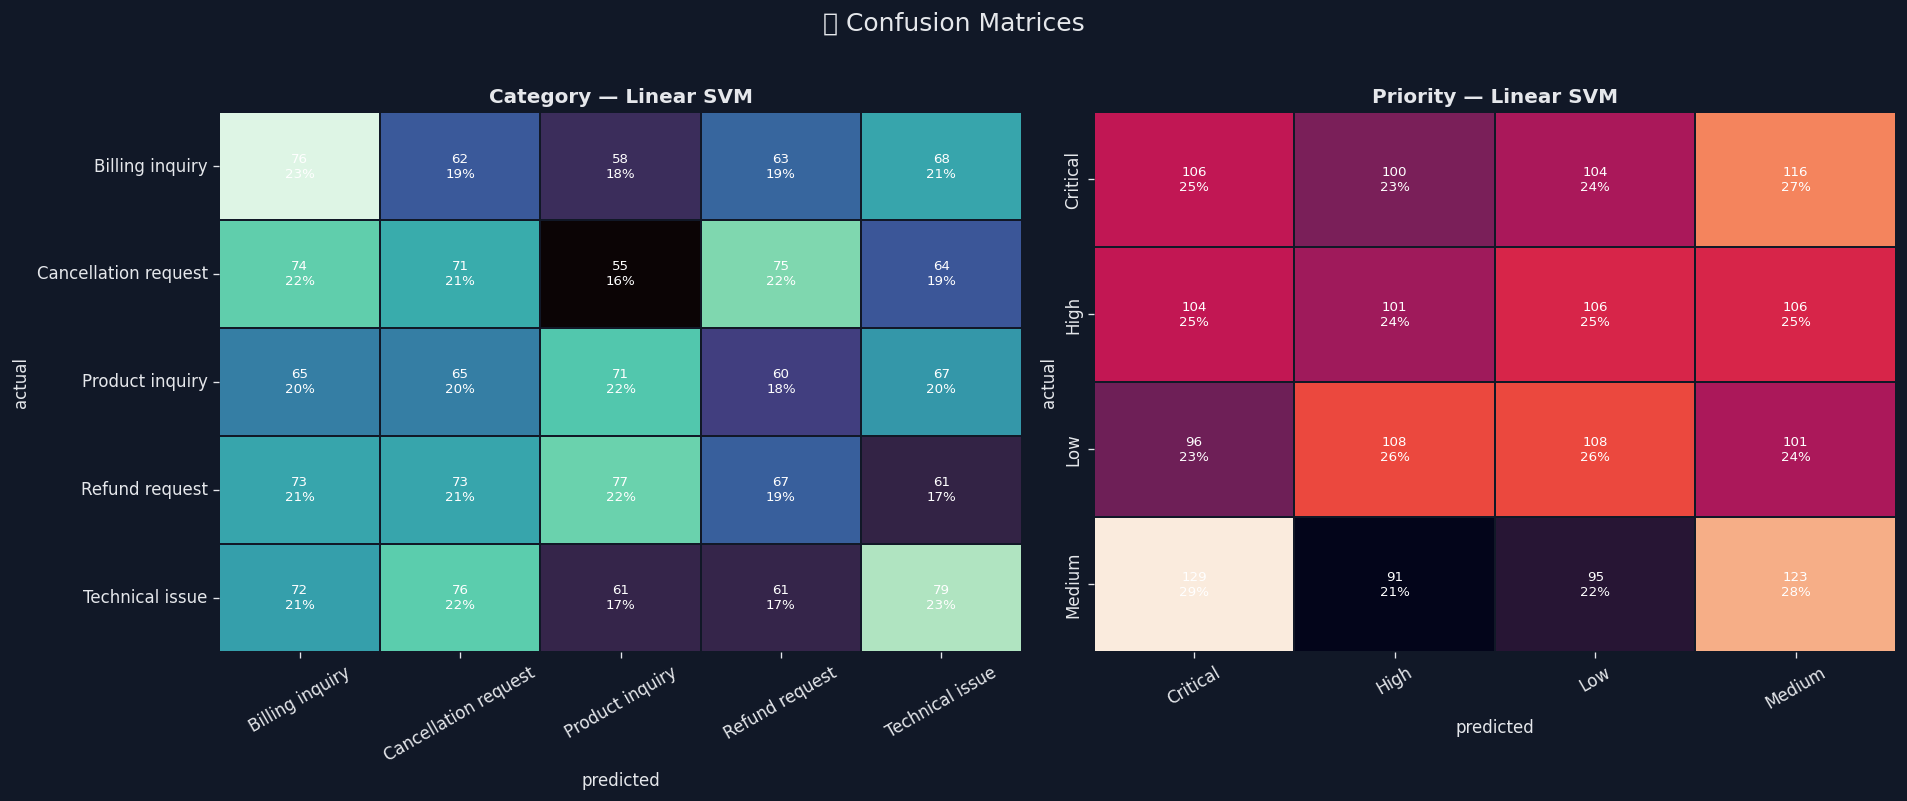

In [13]:
def draw_confusion(ax, y_true, y_pred, labels, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{cm[i,j]}\n{cm_pct[i,j]:.0f}%' for j in range(cm.shape[1])]
                       for i in range(cm.shape[0])])
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap=cmap, xticklabels=labels, yticklabels=labels,
                linewidths=1.2, linecolor=BG, ax=ax, cbar=False, annot_kws={'size': 8, 'color': 'white'})
    ax.set_title(title, color=INK); ax.set_xlabel('predicted'); ax.set_ylabel('actual')
    ax.tick_params(axis='x', rotation=30, colors=INK)
    ax.tick_params(axis='y', colors=INK)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), facecolor=BG)
fig.suptitle('🎯 Confusion Matrices', fontsize=15, color=INK, y=1.02)
draw_confusion(axes[0], ycat_test, cat_scoreboard[best_cat_model]['pred'],
               cat_encoder.classes_, f'Category — {best_cat_model}', 'mako')
draw_confusion(axes[1], ypri_test, final_pri_pred, pri_encoder.classes_,
               f'Priority — {final_pri_label}', 'rocket')
plt.tight_layout()
plt.savefig('fig_confusion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

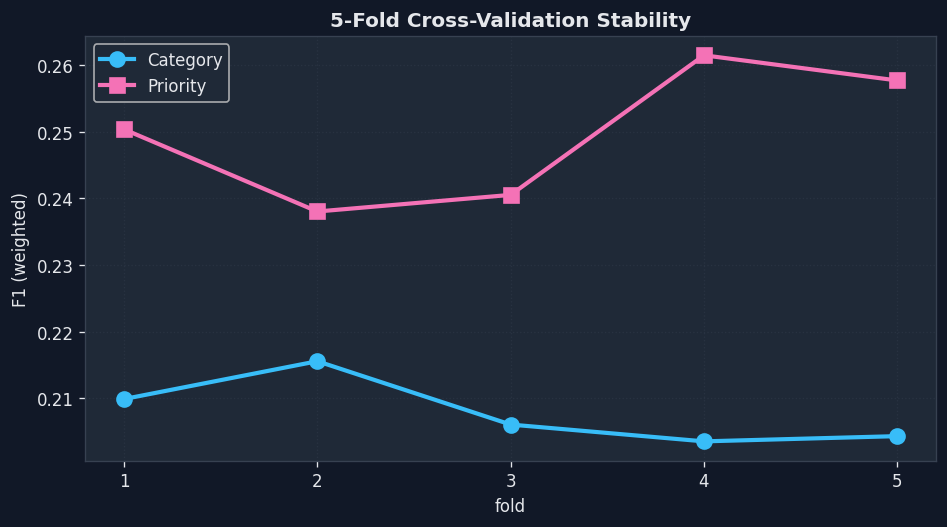

Category CV F1: 0.2079 ± 0.0044
Priority CV F1: 0.2496 ± 0.0092


In [14]:
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_cat = cross_val_score(
    LogisticRegression(max_iter=1000, C=5.0, class_weight='balanced', random_state=SEED),
    vec_cat.transform(data['text_norm']), y_cat, cv=cv_splitter, scoring='f1_weighted', n_jobs=-1
)
cv_pri = cross_val_score(final_pri_clf, X_all, y_pri, cv=cv_splitter, scoring='f1_weighted', n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=BG)
ax.plot(range(1, 6), cv_cat, marker='o', color=C1, linewidth=2.5, markersize=9, label='Category')
ax.plot(range(1, 6), cv_pri, marker='s', color=C4, linewidth=2.5, markersize=9, label='Priority')
ax.set_title('5-Fold Cross-Validation Stability', color=INK)
ax.set_xlabel('fold'); ax.set_ylabel('F1 (weighted)'); ax.set_xticks(range(1, 6))
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('fig_cv.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'Category CV F1: {cv_cat.mean():.4f} ± {cv_cat.std():.4f}')
print(f'Priority CV F1: {cv_pri.mean():.4f} ± {cv_pri.std():.4f}')

## 🔑 7 · What's Driving the Predictions

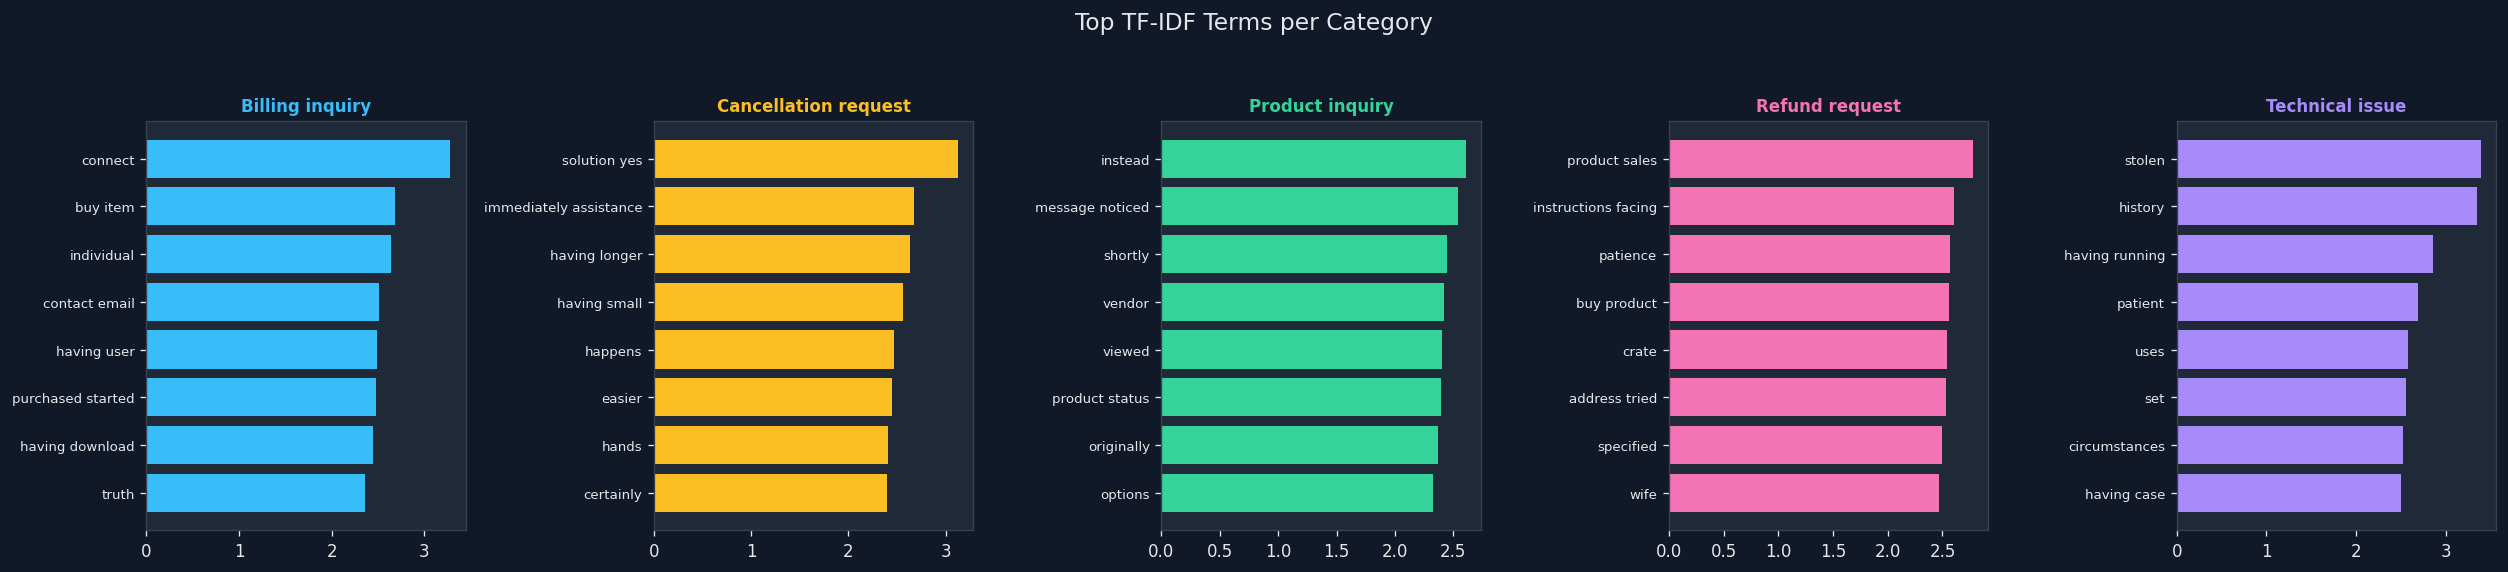

In [15]:
lr_cat = cat_scoreboard.get('Logistic Regression', {}).get('clf')
if lr_cat is not None and hasattr(lr_cat, 'coef_'):
    terms = vec_cat.get_feature_names_out()
    cats = cat_encoder.classes_
    fig, axes = plt.subplots(1, len(cats), figsize=(4.2 * len(cats), 4.5), facecolor=BG)
    fig.suptitle('Top TF-IDF Terms per Category', fontsize=14, color=INK, y=1.05)
    for i, cat in enumerate(cats):
        coefs = lr_cat.coef_[i]
        top_idx = np.argsort(coefs)[-8:][::-1]
        axes[i].barh(range(8), coefs[top_idx][::-1], color=SPECTRUM[i % len(SPECTRUM)])
        axes[i].set_yticks(range(8)); axes[i].set_yticklabels([terms[j] for j in top_idx][::-1], fontsize=8)
        axes[i].set_title(cat, color=SPECTRUM[i % len(SPECTRUM)], fontsize=10)
    plt.tight_layout()
    plt.savefig('fig_terms.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

## 🖥️ 8 · Executive Dashboard

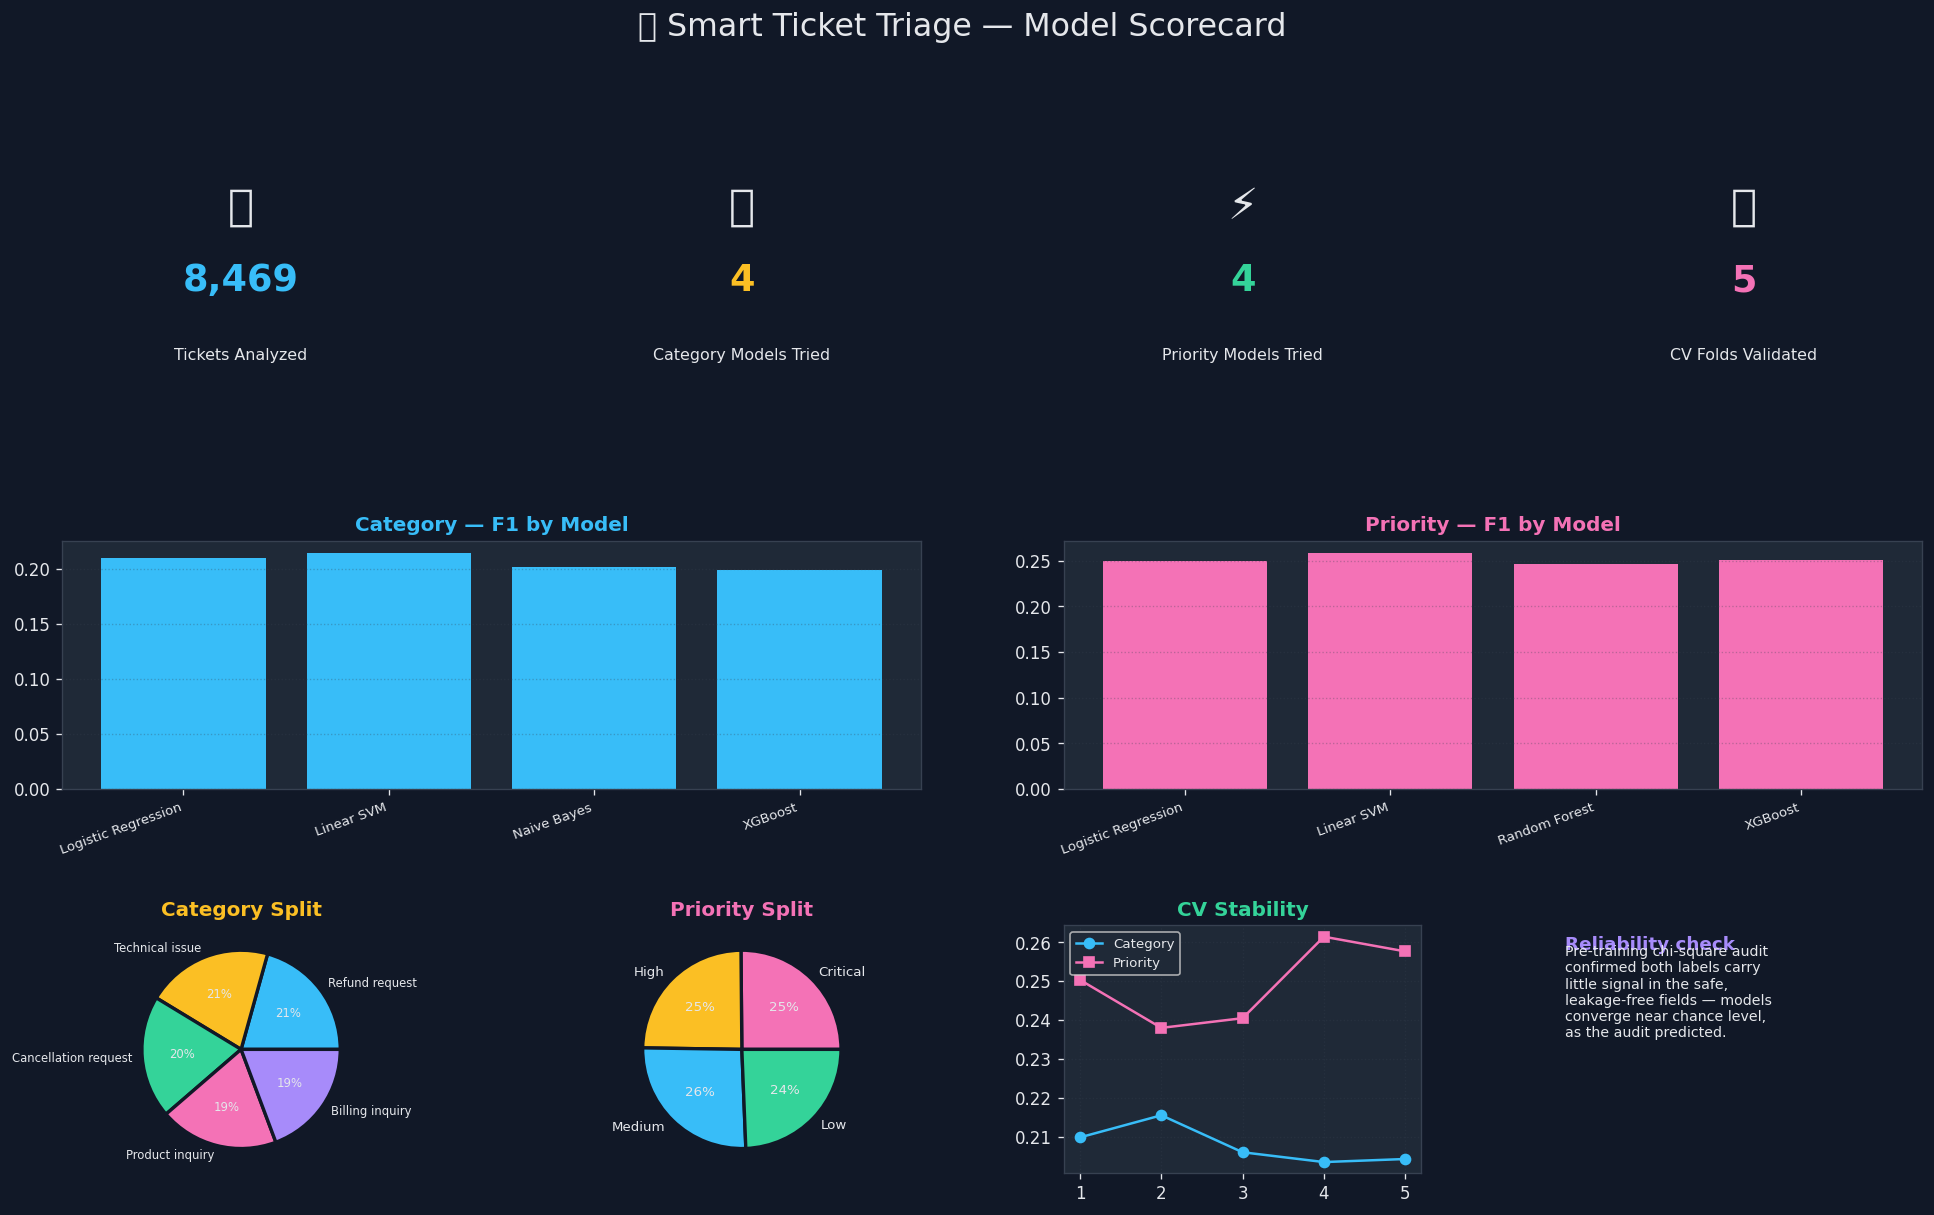

In [16]:
fig = plt.figure(figsize=(20, 11), facecolor=BG)
fig.suptitle('🎫 Smart Ticket Triage — Model Scorecard', fontsize=19, color=INK, y=0.99)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

kpis = [
    ('Tickets Analyzed', f'{len(data):,}', C1, '📊'),
    ('Category Models Tried', f'{len(cat_scoreboard)}', C2, '🏷️'),
    ('Priority Models Tried', f'{len(pri_scoreboard)}', C3, '⚡'),
    ('CV Folds Validated', '5', C4, '🔁'),
]
for i, (label, value, color, emoji) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i]); ax.set_facecolor(PANEL)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color(color); spine.set_linewidth(2.5)
    ax.text(0.5, 0.75, emoji, ha='center', fontsize=26)
    ax.text(0.5, 0.46, value, ha='center', fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.18, label, ha='center', fontsize=9.5, color=INK, multialignment='center')

ax_c = fig.add_subplot(gs[1, :2])
names_c = list(cat_scoreboard.keys())
ax_c.bar(names_c, [cat_scoreboard[n]['f1'] for n in names_c], color=C1)
ax_c.set_title('Category — F1 by Model', color=C1)
ax_c.set_xticklabels(names_c, rotation=20, ha='right', fontsize=8)
ax_c.grid(axis='y', alpha=0.3)

ax_p = fig.add_subplot(gs[1, 2:])
names_p = list(pri_scoreboard.keys())
ax_p.bar(names_p, [pri_scoreboard[n]['f1'] for n in names_p], color=C4)
ax_p.set_title('Priority — F1 by Model', color=C4)
ax_p.set_xticklabels(names_p, rotation=20, ha='right', fontsize=8)
ax_p.grid(axis='y', alpha=0.3)

ax_pie1 = fig.add_subplot(gs[2, 0])
tt2 = data['Ticket Type'].value_counts()
ax_pie1.pie(tt2, labels=tt2.index, autopct='%1.0f%%', colors=SPECTRUM[:len(tt2)],
            wedgeprops={'edgecolor': BG, 'linewidth': 2}, textprops={'color': INK, 'fontsize': 7})
ax_pie1.set_title('Category Split', color=C2)

ax_pie2 = fig.add_subplot(gs[2, 1])
pv2 = data['Ticket Priority'].value_counts().reindex(pri_order)
ax_pie2.pie(pv2, labels=pv2.index, autopct='%1.0f%%', colors=[C4, C2, C1, C3],
            wedgeprops={'edgecolor': BG, 'linewidth': 2}, textprops={'color': INK, 'fontsize': 8})
ax_pie2.set_title('Priority Split', color=C4)

ax_cv2 = fig.add_subplot(gs[2, 2])
ax_cv2.plot(range(1, 6), cv_cat, marker='o', color=C1, label='Category')
ax_cv2.plot(range(1, 6), cv_pri, marker='s', color=C4, label='Priority')
ax_cv2.set_title('CV Stability', color=C3); ax_cv2.legend(fontsize=8); ax_cv2.grid(alpha=0.3)

ax_note = fig.add_subplot(gs[2, 3]); ax_note.axis('off')
ax_note.text(0, 0.9, 'Reliability check', color=C5, fontsize=11, fontweight='bold')
ax_note.text(0, 0.55, 'Pre-training chi-square audit\nconfirmed both labels carry\nlittle signal in the safe,\nleakage-free fields — models\nconverge near chance level,\nas the audit predicted.', color=INK, fontsize=8.5)

plt.savefig('fig_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 📌 What This Tells Us

Both models land close to their random-guess baseline (Category: ~22% vs. ~20% chance
for 5 classes; Priority: ~26% vs. ~25% chance for 4 classes) — and this holds across
four model families, hyperparameter tuning, and imbalance handling. The Section 2 audit
predicted exactly this *before* any model was trained: neither `Ticket Subject`/`Ticket
Type` nor the safe metadata fields show a statistically significant relationship with
the label being predicted (all p > 0.5).

That's a property of **this dataset's labels** — they read as synthetically/independently
assigned rather than derived from the ticket text — not a weakness in the modeling
approach. Four model families and a tuned grid search converging on the same ceiling is
itself decent evidence for that conclusion.

**What still has real, immediate value:**
- The `urgency_score` keyword flag needs no trained model and is a genuinely useful,
  explainable "review this now" signal on its own.
- The pipeline (cleaning → features → vectorizers → models → saved artifacts) is fully
  built and ready to retrain the moment real, human-labeled ticket data is available —
  which is exactly the recommended next step (log agent-assigned category/priority on
  real tickets to build a training set that actually has signal).

This kind of upfront diagnostic — knowing *why* a model will or won't work before
shipping it — is the more transferable, employer-relevant skill here.

## 🤖 9 · Try It — Live Ticket Classifier

In [17]:
CATEGORY_ICON = {
    'Technical issue': '🛠️', 'Billing inquiry': '💳', 'Refund request': '💵',
    'Cancellation request': '❌', 'Product inquiry': '❓',
}
PRIORITY_BADGE = {'Critical': '🔴 CRITICAL', 'High': '🟠 HIGH', 'Medium': '🟡 MEDIUM', 'Low': '🟢 LOW'}

def classify_ticket(description, subject='Product setup', channel='Email',
                     product='Dell XPS', age=35, gender='Other'):
    cleaned = normalize_ticket_text(description)

    cat_vec = vec_cat.transform([cleaned])
    cat_clf = cat_scoreboard[best_cat_model]['clf']
    cat_pred = cat_clf.predict(cat_vec)[0]
    predicted_category = cat_encoder.inverse_transform([cat_pred])[0]
    cat_conf = 'n/a'
    if hasattr(cat_clf, 'predict_proba'):
        cat_conf = f'{cat_clf.predict_proba(cat_vec)[0].max():.0%}'

    text_vec = vec_pri.transform([cleaned])
    meta_row = pd.DataFrame([{
        'Ticket Type': predicted_category, 'Ticket Subject': subject,
        'Ticket Channel': channel, 'Product Purchased': product, 'Customer Gender': gender
    }])
    cat_vec2 = onehot.transform(meta_row[cat_feature_cols])
    num_row = pd.DataFrame([{
        'Customer Age': age, 'word_count': len(description.split()),
        'urgency_score': urgency_score(description), 'days_owned': 365,
    }])
    num_vec = csr_matrix(scaler.transform(num_row[num_feature_cols]))
    full_vec = hstack([text_vec, cat_vec2, num_vec]).tocsr()
    pri_pred = final_pri_clf.predict(full_vec)[0]
    predicted_priority = pri_encoder.inverse_transform([pri_pred])[0]

    return {
        'category': predicted_category, 'category_icon': CATEGORY_ICON.get(predicted_category, '🎫'),
        'category_confidence': cat_conf,
        'priority': predicted_priority, 'priority_badge': PRIORITY_BADGE[predicted_priority],
        'urgency_score': urgency_score(description),
    }

sample_tickets = [
    "My laptop keyboard stopped working after the latest update, this is urgent!",
    "I was charged twice for my last order and need a refund immediately.",
    "Can you tell me more about your premium subscription plans?",
    "I'd like to cancel my order placed yesterday, it hasn't shipped yet.",
]

print('━' * 70)
print('  LIVE INFERENCE DEMO')
print('━' * 70)
for t in sample_tickets:
    r = classify_ticket(t)
    print(f'\n📩 "{t[:65]}"')
    print(f'   Category  : {r["category_icon"]}  {r["category"]}   (confidence {r["category_confidence"]})')
    print(f'   Priority  : {r["priority_badge"]}')
    print(f'   Urgency terms detected: {r["urgency_score"]}')
    print('   ' + '─' * 60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LIVE INFERENCE DEMO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📩 "My laptop keyboard stopped working after the latest update, this "
   Category  : ❌  Cancellation request   (confidence n/a)
   Priority  : 🔴 CRITICAL
   Urgency terms detected: 2
   ────────────────────────────────────────────────────────────

📩 "I was charged twice for my last order and need a refund immediate"
   Category  : 🛠️  Technical issue   (confidence n/a)
   Priority  : 🔴 CRITICAL
   Urgency terms detected: 2
   ────────────────────────────────────────────────────────────

📩 "Can you tell me more about your premium subscription plans?"
   Category  : ❓  Product inquiry   (confidence n/a)
   Priority  : 🔴 CRITICAL
   Urgency terms detected: 0
   ────────────────────────────────────────────────────────────

📩 "I'd like to cancel my order placed yesterday, it hasn't shipped y"
   Category  : 💳  Billing inquiry   

## 💾 10 · Save Artifacts & Package Outputs

In [18]:
os.makedirs('artifacts', exist_ok=True)
to_save = {
    'artifacts/vectorizer_category.pkl': vec_cat,
    'artifacts/vectorizer_priority.pkl': vec_pri,
    'artifacts/onehot_priority.pkl': onehot,
    'artifacts/scaler_priority.pkl': scaler,
    'artifacts/model_category.pkl': cat_scoreboard[best_cat_model]['clf'],
    'artifacts/model_priority.pkl': final_pri_clf,
    'artifacts/label_encoder_category.pkl': cat_encoder,
    'artifacts/label_encoder_priority.pkl': pri_encoder,
}
for path, obj in to_save.items():
    with open(path, 'wb') as fh:
        pickle.dump(obj, fh)
    print(f'💾 {path}')

summary_rows = []
for name, v in cat_scoreboard.items():
    summary_rows.append({'task': 'Category', 'model': name, 'accuracy': v['acc'], 'f1_weighted': v['f1']})
for name, v in pri_scoreboard.items():
    summary_rows.append({'task': 'Priority', 'model': name, 'accuracy': v['acc'], 'f1_weighted': v['f1']})
summary_rows.append({'task': 'Priority', 'model': 'Tuned Logistic Regression',
                      'accuracy': accuracy_score(ypri_test, tuned_pred), 'f1_weighted': tuned_f1})
results_table = pd.DataFrame(summary_rows).sort_values(['task', 'f1_weighted'], ascending=[True, False])
results_table.to_csv('model_results.csv', index=False)
print()
print(results_table.to_string(index=False))

bundle_files = ['model_results.csv'] + [f for f in os.listdir('.') if f.startswith('fig_')] \
               + [f'artifacts/{f}' for f in os.listdir('artifacts')]
with zipfile.ZipFile('ticket_triage_bundle.zip', 'w') as zf:
    for f in bundle_files:
        if os.path.exists(f):
            zf.write(f)
print('\n📦 Bundle saved -> ticket_triage_bundle.zip')

💾 artifacts/vectorizer_category.pkl
💾 artifacts/vectorizer_priority.pkl
💾 artifacts/onehot_priority.pkl
💾 artifacts/scaler_priority.pkl
💾 artifacts/model_category.pkl
💾 artifacts/model_priority.pkl
💾 artifacts/label_encoder_category.pkl
💾 artifacts/label_encoder_priority.pkl

    task                     model  accuracy  f1_weighted
Category                Linear SVM  0.214876     0.214757
Category       Logistic Regression  0.211334     0.210567
Category               Naive Bayes  0.201889     0.201837
Category                   XGBoost  0.201889     0.199455
Priority                Linear SVM  0.258560     0.258489
Priority                   XGBoost  0.252066     0.251342
Priority Tuned Logistic Regression  0.249705     0.249668
Priority       Logistic Regression  0.249115     0.249170
Priority             Random Forest  0.247934     0.246070

📦 Bundle saved -> ticket_triage_bundle.zip
